# Topic 1 – Data Loading

## Simple Concept

**Data Loading** means loading the dataset into Python so we can use it for machine learning.

For this notebook, we will use the **Breast Cancer Classification dataset** available directly from Scikit-learn.

It is suitable for learning ANN classification because:

- It has multiple features.
- It has a binary target.
- It does not require downloading a CSV file.
- It works well for comparing **Logistic Regression vs ANN**.



## What This Code Does

- `load_breast_cancer()` → loads the dataset.
- `data.data` → contains the input features.
- `data.feature_names` → contains feature names.
- `data.target` → contains the target values.
- `pd.DataFrame()` → converts the data into a DataFrame.

## Target

```text
0 → Malignant
1 → Benign
```

So this is a **binary classification problem**.

## Key Point

**Data Loading → Dataset available → Ready for inspection and preprocessing**

In [2]:
## Python Implementation

from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
data = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)

# Add target column
df["target"] = data.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


# Topic 2 – Data Inspection

## Simple Concept

**Data Inspection** means checking the dataset before preprocessing and training the ANN.

We mainly check:

- Number of rows and columns
- Data types
- Missing values
- Target distribution
- Basic statistics


## What This Tells Us

- **569 rows** → 569 patient records.
- **30 input features + 1 target**.
- **0 missing values** → no missing-value treatment is required.
- Target contains **two classes** → binary classification.
- `describe()` helps us understand feature ranges.

## Key Point

Before training a model, always **inspect the data first**.

**Load Data → Inspect Data → Preprocess Data**

In [3]:

## Python Implementation

# Dataset shape
print("Shape:", df.shape)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Target distribution
print("\nTarget Distribution:")
print(df["target"].value_counts())

# Basic statistics
print("\nStatistics:")
print(df.describe())


Shape: (569, 31)

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points     

# Topic 3 – Data Preprocessing

## Simple Concept

**Data preprocessing** means preparing the dataset so it can be given to the ANN.

For this dataset:

- There are no missing values.
- All input features are numerical.
- The `target` column is the output.
- We should separate **features (X)** and **target (y)**.



## What This Code Does

```python
X = df.drop("target", axis=1)
```

Removes the target column and stores the **input features** in `X`.

```python
y = df["target"]
```

Stores the target/output in `y`.

So:

```text
X → Input features
y → Target/output
```

## Key Point

For machine learning:

**Features → X**

**Target → y**

The ANN learns the relationship between **X and y**.

In [4]:
## Python Implementation

# Separate features and target

X = df.drop("target", axis=1)
y = df["target"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (569, 30)
Target shape: (569,)


# Topic 4 – Feature Engineering

## Simple Concept

**Feature engineering** means creating, modifying, or selecting features to help a model learn better.

For this dataset, the features are already prepared and meaningful.

So, **we do not need to create new features** for this notebook.

We will simply use the existing 30 features.


## What This Tells Us

The dataset already contains useful measurements such as:

```text
mean radius
mean texture
mean perimeter
mean area
mean smoothness
...
```

These features can be directly used by the ANN.

## Key Point

Not every dataset requires feature engineering.

Here:

**Existing features → Suitable → Use directly**

Next, we will split the data into **training and testing sets**.

In [6]:
## Python Implementation

# Check available features

print(X.columns.tolist())



['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


# Topic 5 – Train/Test Split

## Simple Concept

**Train/Test Split** means dividing the dataset into two parts:

- **Training data** → used to train the ANN.
- **Testing data** → used to evaluate the ANN on unseen data.

We will use **80% for training** and **20% for testing**.


## What This Code Does

```python
test_size=0.2
```

Uses **20% of the data for testing**.

```python
random_state=42
```

Makes the split reproducible.

```python
stratify=y
```

Keeps the class distribution similar in training and testing data.

## Key Point

```text
569 records
     ↓
80% → Training → 455 records
20% → Testing  → 114 records
```

**Training data → Learn**

**Testing data → Evaluate**

In [7]:

## Python Implementation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (455, 30)
Testing data: (114, 30)


# Topic 6 – Feature Scaling

## Simple Concept

**Feature scaling** brings all input features to a similar range.

This is important for an **ANN** because neural networks use weights and gradient-based optimization.

Some features may have large values while others have small values.

For example:

```text
Feature A → 0.1 to 1
Feature B → 10 to 100
Feature C → 1000 to 5000
```

Large-scale features can affect training.


## Important

We use:

```python
scaler.fit_transform(X_train)
```

for training data.

For testing data, we use:

```python
scaler.transform(X_test)
```

We **do not fit the scaler on test data**.

This prevents information from the test set leaking into the training process.

## What This Code Does

`StandardScaler` standardizes the features so they have approximately:

```text
Mean → 0
Standard deviation → 1
```

## Key Point

**Before scaling:**

```text
Different feature ranges
        ↓
Possible difficult ANN training
```

**After scaling:**

```text
Similar feature scale
        ↓
Better ANN training
```

In [8]:

## Python Implementation

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)


Training data shape: (455, 30)
Testing data shape: (114, 30)


# Topic 7 – Tensor Conversion

## Simple Concept

**Tensor conversion** means converting our data from Pandas/NumPy format into **PyTorch tensors**.

PyTorch ANN models work with tensors.

We need:

```text
X_train → Tensor
X_test  → Tensor
y_train → Tensor
y_test  → Tensor
```


## What This Code Does

```python
dtype=torch.float32
```

Converts the values into a format commonly used by PyTorch neural networks.

```python
.view(-1, 1)
```

Changes the target shape from:

```text
455
```

to:

```text
455 × 1
```

This matches the ANN's single output.

## Key Point

```text
Scaled NumPy data
       ↓
PyTorch Tensor
       ↓
Ready for ANN
```

In [9]:
## Python Implementation

import torch

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("X_train:", X_train_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("y_test:", y_test_tensor.shape)


X_train: torch.Size([455, 30])
X_test: torch.Size([114, 30])
y_train: torch.Size([455, 1])
y_test: torch.Size([114, 1])


# Topic 8 – ANN Architecture

## Simple Concept

**ANN architecture** defines how the neural network is structured.

For our dataset:

- Input features = **30**
- Hidden layer = **16 neurons**
- Hidden layer = **8 neurons**
- Output = **1 neuron**

Architecture:

```text
30 Inputs
   ↓
Linear Layer (16)
   ↓
ReLU
   ↓
Linear Layer (8)
   ↓
ReLU
   ↓
Linear Layer (1)
   ↓
Output
```

## What This Code Does

```python id="xq8w2k"
nn.Linear(30, 16)
```

Takes **30 input features** and produces **16 values**.

```python id="j9v3ra"
nn.ReLU()
```

Adds non-linearity so the ANN can learn more complex relationships.

```python id="2c7n1m"
nn.Linear(16, 8)
```

Reduces the information from 16 values to 8.

```python id="u5d4ks"
nn.Linear(8, 1)
```

Produces **one output** for binary classification.

## Key Point

```text
Input → Hidden → Activation → Hidden → Activation → Output
 30        16          ReLU        8          ReLU       1
```

This is the basic ANN architecture we will train in the next topic.

In [10]:

## Python Implementation

import torch.nn as nn

model = nn.Sequential(
    nn.Linear(30, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1)
)

print(model)


Sequential(
  (0): Linear(in_features=30, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
)


# Topic 9 – Model Training

## Simple Concept

**Model training** means teaching the ANN to learn the relationship between the input features and the target.

During training:

```text
Input
  ↓
Forward Pass
  ↓
Prediction
  ↓
Loss
  ↓
Backpropagation
  ↓
Weight Update
```

We will use:

- **BCEWithLogitsLoss** → loss function for binary classification
- **Adam** → optimizer
- **100 epochs** → number of training iterations


## Output

You should see the loss generally decreasing:

```text
Epoch [10/100], Loss: 0.XXXX
Epoch [20/100], Loss: 0.XXXX
...
Epoch [100/100], Loss: 0.XXXX
```

The exact values may vary.

## What This Code Does

### `criterion`

Calculates how wrong the ANN's predictions are.

### `optimizer`

Updates the ANN's weights to reduce the loss.

### `loss.backward()`

Calculates gradients.

### `optimizer.step()`

Updates the model's weights using those gradients.

## Key Point

The ANN learns by repeatedly doing:

**Predict → Calculate Loss → Calculate Gradients → Update Weights**

This process happens for every epoch.

In [11]:
## Python Implementation

import torch.nn as nn
import torch.optim as optim

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 100

for epoch in range(epochs):

    # Forward pass
    outputs = model(X_train_tensor)

    # Calculate loss
    loss = criterion(outputs, y_train_tensor)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")



Epoch [10/100], Loss: 0.7353
Epoch [20/100], Loss: 0.7042
Epoch [30/100], Loss: 0.6702
Epoch [40/100], Loss: 0.6296
Epoch [50/100], Loss: 0.5811
Epoch [60/100], Loss: 0.5242
Epoch [70/100], Loss: 0.4615
Epoch [80/100], Loss: 0.3973
Epoch [90/100], Loss: 0.3358
Epoch [100/100], Loss: 0.2807


# Topic 10 – Validation

## Simple Concept

**Validation** means checking how well the ANN performs on data that was **not used to update its weights**.

For this notebook, we will use the **test set as a simple evaluation set**.

```text id="y5c1v9"
Training data → Train the ANN
Testing data  → Check performance
```


## What This Code Does

```python id="z3gq4f"
model.eval()
```

Puts the ANN into **evaluation mode**.

```python id="k2f8pd"
torch.no_grad()
```

Stops gradient calculation because we are not training the model.

```python id="v8n4sx"
test_outputs = model(X_test_tensor)
```

Generates predictions for the unseen test data.

```python id="q6m1rt"
test_loss = criterion(test_outputs, y_test_tensor)
```

Calculates how much error the model has on the test data.

## Key Point

During training:

**Weights are updated.**

During validation/evaluation:

**Weights are not updated.**

A lower test loss generally means the ANN is making predictions closer to the actual targets.

In [12]:

## Python Implementation

model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)

    test_loss = criterion(test_outputs, y_test_tensor)

print("Test Loss:", test_loss.item())


Test Loss: 0.3164864480495453


# Topic 11 – Prediction

## Simple Concept

**Prediction** means using the trained ANN to predict the class of new/unseen data.

Our ANN produces a raw output called a **logit**.

For binary classification, we convert the logit into a probability using **Sigmoid**.

```text
ANN Output
    ↓
Sigmoid
    ↓
Probability
    ↓
Threshold 0.5
    ↓
Class 0 or 1
```


## What This Code Does

### `torch.sigmoid()`

Converts the ANN's raw output into a probability between **0 and 1**.

Example:

```text
0.02 → 2% probability
0.97 → 97% probability
```

### `>= 0.5`

Uses **0.5 as the classification threshold**.

```text
Probability < 0.5 → Class 0
Probability ≥ 0.5 → Class 1
```

## Key Point

The ANN first produces a **probability**, then we convert that probability into the final **class prediction**.

In [13]:

## Python Implementation

import torch

model.eval()

with torch.no_grad():
    logits = model(X_test_tensor)

    probabilities = torch.sigmoid(logits)

    predictions = (probabilities >= 0.5).float()

print("Probabilities:")
print(probabilities[:5])

print("\nPredictions:")
print(predictions[:5])


Probabilities:
tensor([[0.0459],
        [0.9131],
        [0.1736],
        [0.5398],
        [0.0448]])

Predictions:
tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])


# Topic 12 – Evaluation

## Simple Concept

**Evaluation** means measuring how well the trained ANN performs on the test data.

For classification, we will calculate:

- Accuracy
- Precision
- Recall
- F1-score

The exact values may vary.

## What Each Metric Tells Us

**Accuracy** → Overall correct predictions.

**Precision** → How many predicted positives were actually positive.

**Recall** → How many actual positives were correctly detected.

**F1-score** → Balance between precision and recall.

## Key Point

Do not judge a classification model using **accuracy alone**.

Use multiple metrics to understand model performance.

In [14]:

## Python Implementation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Convert tensors to NumPy arrays
y_true = y_test_tensor.numpy().flatten()
y_pred = predictions.numpy().flatten()

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)


Accuracy : 0.9122807017543859
Precision: 0.9428571428571428
Recall   : 0.9166666666666666
F1-Score : 0.9295774647887324


# Topic 13 – Confusion Matrix

## Simple Concept

A **Confusion Matrix** shows how many predictions were correct and incorrect for each class.

It contains:

- **True Positive (TP)** → Actual 1, predicted 1
- **True Negative (TN)** → Actual 0, predicted 0
- **False Positive (FP)** → Actual 0, predicted 1
- **False Negative (FN)** → Actual 1, predicted 0


For example:

```text id="r2y7pk"
[[40  2]
 [ 1 71]]
```

This means:

```text id="z8j4sx"
40 → Correct Class 0 predictions
 2 → Class 0 predicted as Class 1
 1 → Class 1 predicted as Class 0
71 → Correct Class 1 predictions
```

## Why It Is Useful

Accuracy tells us **how many predictions were correct overall**.

The confusion matrix tells us **where the model made mistakes**.

## Key Point

```text id="5rj3qn"
Confusion Matrix
      ↓
Correct predictions + Incorrect predictions
      ↓
Understand model errors
```

[[38  4]
 [ 6 66]]


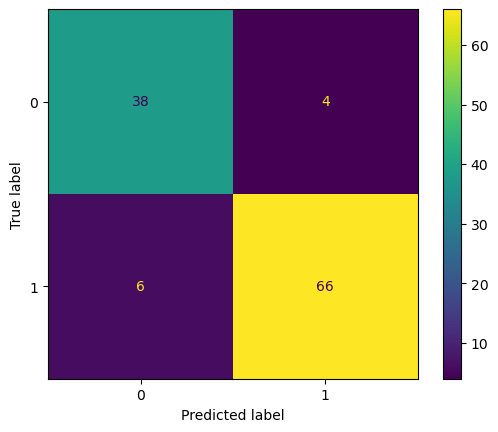

In [15]:
## Python Implementation

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()



# Topic 14 – ROC-AUC

## Simple Concept

**ROC-AUC** measures how well the model separates the two classes across different classification thresholds.

- **ROC** → Receiver Operating Characteristic curve
- **AUC** → Area Under the Curve

AUC ranges from **0 to 1**.

```text id="z5k8pp"
1.0 → Excellent separation
0.5 → Random-like separation
< 0.5 → Poor separation
```



## What This Code Does

```python id="w7k4ds"
roc_auc_score(...)
```

Calculates the **ROC-AUC score** using the predicted probabilities.

```python id="m2p6qx"
roc_curve(...)
```

Calculates the points needed to draw the ROC curve.

## Important

ROC-AUC uses **probabilities**, not only the final `0` or `1` predictions.

That is why we use:

```python id="4h9v2s"
probabilities
```

instead of:

```python id="5x7n1a"
predictions
```

## Key Point

**ROC-AUC → Measures how well the ANN separates the two classes across different thresholds.**

ROC-AUC: 0.9874338624338624


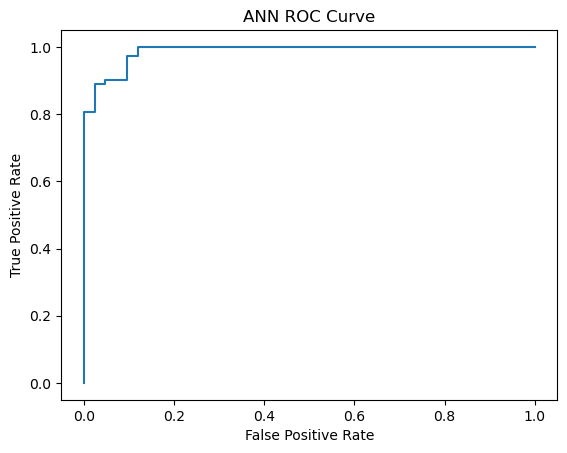

In [16]:
## Python Implementation

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Calculate ROC-AUC
auc = roc_auc_score(y_true, probabilities.numpy().flatten())

print("ROC-AUC:", auc)

# ROC curve
fpr, tpr, thresholds = roc_curve(
    y_true,
    probabilities.numpy().flatten()
)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ANN ROC Curve")
plt.show()


# Topic 15 – Logistic Regression vs ANN

## Simple Concept

We will compare our **ANN** with **Logistic Regression** on the same dataset.

Both models will use:

- Same training data
- Same testing data
- Same scaled features

This makes the comparison fair.


## What We Learn

The model with the higher metric value performed better **for that particular metric and dataset**.

Do not look only at accuracy.

Compare:

```text
Accuracy
Precision
Recall
F1-Score
ROC-AUC
```

## Key Point

**Same dataset + same train/test split + same features → Fair model comparison**

In [18]:

## Python Implementation
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
lr_predictions = lr_model.predict(X_test_scaled)
lr_probabilities = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)
lr_auc = roc_auc_score(y_test, lr_probabilities)

print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-Score :", lr_f1)
print("ROC-AUC  :", lr_auc)


Logistic Regression
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall   : 0.9861111111111112
F1-Score : 0.9861111111111112
ROC-AUC  : 0.9953703703703703


In [19]:
## Compare Results

#Create a comparison table using the ANN results and Logistic Regression results:

#```python
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_auc
    ],
    "ANN": [
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]
})

comparison


,Metric,Logistic Regression,ANN
0,Accuracy,0.982456,0.912281
1,Precision,0.986111,0.942857
2,Recall,0.986111,0.916667
3,F1-Score,0.986111,0.929577
4,ROC-AUC,0.995370,0.987434


In [ ]:
# Topic 16 – Performance Comparison

## Simple Concept

Now we compare **Logistic Regression and ANN** beyond just prediction metrics.

We consider:

- Performance
- Training time
- Complexity
- Interpretability
- Dataset size
- Resource requirements

## Comparison

| Factor | Logistic Regression | ANN |
|---|---|---|
| Model complexity | Low | Higher |
| Interpretability | Easier | More difficult |
| Training time | Usually faster | Usually slower |
| Dataset size | Works well with smaller datasets | Often benefits from more data |
| Resources | Low | Higher |
| Non-linear relationships | Limited | Can learn complex non-linear relationships |
| Tuning | Relatively simple | More parameters to tune |

## Training Time

We can measure training time for both models.

```python id="j5q8fd"
import time

# Logistic Regression training time
start = time.time()

lr_model.fit(X_train_scaled, y_train)

lr_time = time.time() - start

# ANN training time
start = time.time()

for epoch in range(100):
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

ann_time = time.time() - start

print("Logistic Regression training time:", lr_time)
print("ANN training time:", ann_time)
```

## How to Interpret the Comparison

There is **no universal winner**.

For this particular dataset, look at the actual results:

```text id="k4z7pm"
Metrics
   ↓
Accuracy
Precision
Recall
F1
ROC-AUC
   ↓
Compare

Then consider:

Training Time
Complexity
Interpretability
Resources
```

If the ANN gives similar performance to Logistic Regression while requiring more complexity and resources, that is an important observation.

If the ANN performs substantially differently, investigate **why** by considering the dataset size, feature relationships, architecture, and training settings.

## Key Point

**Model selection is not only about getting the highest accuracy.**

Choose a model based on:

**Performance + Complexity + Interpretability + Resources + Dataset characteristics**